Image classification using CNN

In [1]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

LOAD THE DATA SET

In [2]:
(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()
X_train.shape

c:\Users\hp\OneDrive\Desktop\ml\image classification using cnn\venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


(50000, 32, 32, 3)

In [3]:
X_test.shape

(10000, 32, 32, 3)

In [4]:
# 2. Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

In [6]:
# 3. One-hot encoding
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


In [7]:
# 4. Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

c:\Users\hp\OneDrive\Desktop\ml\image classification using cnn\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# 5. Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# 6. Train
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.4108 - loss: 1.6179 - val_accuracy: 0.5380 - val_loss: 1.3014
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.5468 - loss: 1.2806 - val_accuracy: 0.6266 - val_loss: 1.0773
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.5917 - loss: 1.1580 - val_accuracy: 0.6469 - val_loss: 1.0052
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.6210 - loss: 1.0772 - val_accuracy: 0.6641 - val_loss: 0.9674
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.6430 - loss: 1.0210 - val_accuracy: 0.6745 - val_loss: 0.9436
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.6593 - loss: 0.9721 - val_accuracy: 0.6730 - val_loss: 0.9262
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6733 - loss: 0.9308 - val_accuracy: 0.6874 - val_loss: 0.8942
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - accuracy: 0.6885 - 

In [10]:
# 7. Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6925 - loss: 0.8848
Test Accuracy: 0.6924999952316284


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


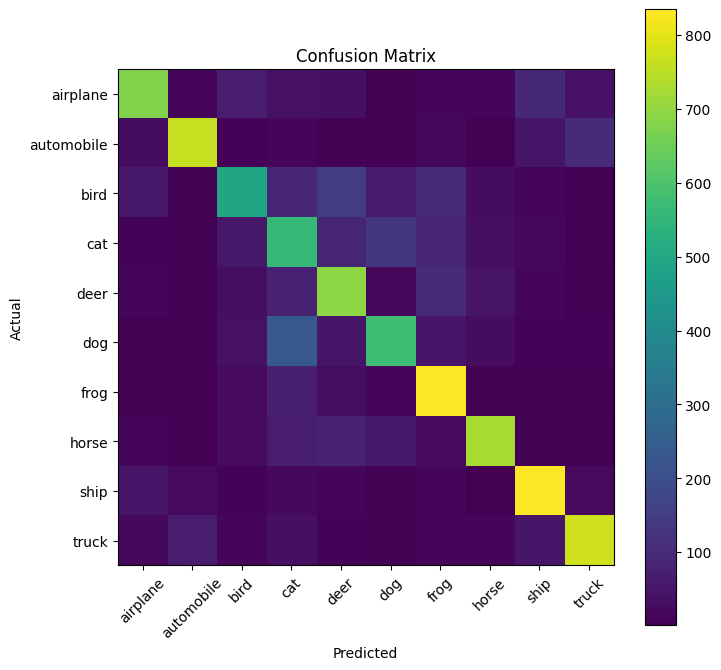

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
# 1. Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
# 2. Convert true labels (if one-hot encoded)
y_true = np.argmax(y_test, axis=1)
# 3. Create confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
# 4. Plot
plt.figure(figsize=(8,8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
# Save the model to a file
model.save('cifar10_model.h5')
print("Model saved successfully!")

Model saved successfully!
